   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

100%|██████████| 18605/18605 [07:27<00:00, 41.59it/s]


Train pre-load complete.
Client sizes: [5304, 11772, 1529] ✅

RUNNING FEDPROX
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


  Round 1/20 fedprox → val F1: 0.4937
  Round 2/20 fedprox → val F1: 0.5731
  Round 3/20 fedprox → val F1: 0.6152
  Round 4/20 fedprox → val F1: 0.6466
  Round 5/20 fedprox → val F1: 0.7098
  Round 6/20 fedprox → val F1: 0.7217
  Round 7/20 fedprox → val F1: 0.7418
  Round 8/20 fedprox → val F1: 0.7458
  Round 9/20 fedprox → val F1: 0.7539
  Round 10/20 fedprox → val F1: 0.7758
  Round 11/20 fedprox → val F1: 0.7924
  Round 12/20 fedprox → val F1: 0.7959
  Round 13/20 fedprox → val F1: 0.7733
  Round 14/20 fedprox → val F1: 0.8055
  Round 15/20 fedprox → val F1: 0.7919
  Round 16/20 fedprox → val F1: 0.7867
  Round 17/20 fedprox → val F1: 0.7927
  Round 18/20 fedprox → val F1: 0.7963
  Round 19/20 fedprox → val F1: 0.8109
  Round 20/20 fedprox → val F1: 0.8350
✅ fedprox → Acc=0.7079  F1=0.5501

RUNNING DITTO
  Round 1/20 ditto → val F1: 0.4694
  Round 2/20 ditto → val F1: 0.5979
  Round 3/20 ditto → val F1: 0.6228
  Round 4/20 ditto → val F1: 0.6597
  Round 5/20 ditto → val F1: 0.7199


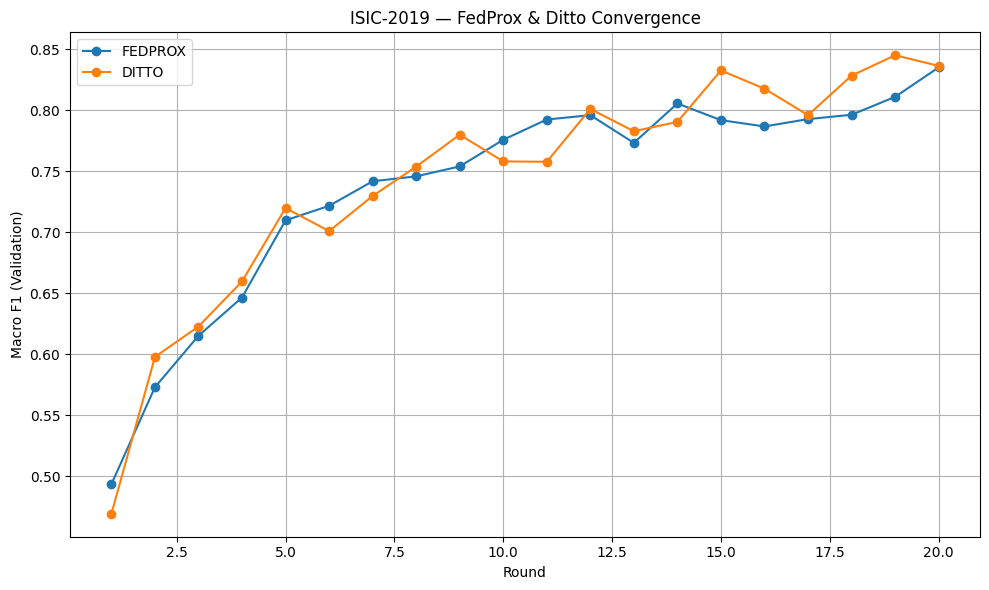


✅ Notebook 1B complete. Outputs saved.
Files: fl_results_part_b.csv, ablation_part_b.csv
       final_model_fedprox.pth, final_model_ditto.pth
       client_fedprox_*.pth, client_ditto_*.pth

➡ Save this notebook's output as dataset 'isic-fl-part-b'
➡ Then open Notebook 2 (validation), add both 'isic-fl-part-a' and 'isic-fl-part-b' as inputs


In [1]:
# ==========================================
# NOTEBOOK 1B: ISIC-2019 FL TRAINING
# Methods: FedProx + Ditto
# Requires: Notebook 1A output added as dataset 'isic-fl-part-a'
# Includes: main run (20 rounds) + ablation (10 rounds × 2 fracs)
# ==========================================

!pip install -q scikit-learn torchmetrics tqdm

import os, copy, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score
)
import matplotlib.pyplot as plt
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# PATH TO NOTEBOOK 1A OUTPUTS
# After adding 'isic-fl-part-a' as a dataset input,
# the path will be shown in the Data panel on the right.
# Update PART_A_PATH if your dataset name differs.
# ==========================================
PART_A_PATH = "/kaggle/input/datasets/setu295452/isic-fl-part-a"
print(f"Loading Notebook 1A assets from: {PART_A_PATH}")

# Load shared assets from 1A
with open(os.path.join(PART_A_PATH,"meta.json")) as f:
    meta = json.load(f)
class_to_idx                = meta['class_to_idx']
class_names                 = meta['class_names']
majority_classes_per_client = meta['majority_classes_per_client']
num_classes                 = len(class_names)
print(f"Classes: {class_to_idx}")

# ==========================================
# 1. DATASET LOADING
# ==========================================
DATA_DIR = "/kaggle/input/isic-2019-skin-lesion-images-for-classification"
if not os.path.exists(DATA_DIR):
    import kagglehub
    DATA_DIR = kagglehub.dataset_download(
        "salviohexia/isic-2019-skin-lesion-images-for-classification")

image_paths = {}
for cn in ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']:
    cd=os.path.join(DATA_DIR,cn)
    if not os.path.isdir(cd): continue
    for fname in os.listdir(cd):
        if fname.endswith('.jpg'):
            base=fname.replace('_downsampled.jpg','').replace('.jpg','')
            image_paths[base]=os.path.join(cd,fname)
print(f"Found {len(image_paths)} images.")

# Reload full df with same split (random_state=42 guarantees identical split)
csv_path = os.path.join(DATA_DIR,"ISIC_2019_Training_GroundTruth.csv")
df       = pd.read_csv(csv_path)
lesion_cols  = ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']
df['target'] = df[lesion_cols].idxmax(axis=1)
df['label']  = df['target'].map(class_to_idx)
df['image_base'] = df['image']
df = df[df['image_base'].isin(image_paths.keys())]
df = df[df['label'].notna()].reset_index(drop=True)
df['label'] = df['label'].astype(int)

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# ==========================================
# 2. PRE-LOAD TRAIN IMAGES
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

print("Pre-loading TRAIN images...")
train_tensors, train_labels = [], []
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    try:
        img = Image.open(image_paths[row['image_base']]).convert("RGB")
        train_tensors.append(transform(img))
    except Exception:
        train_tensors.append(torch.zeros(3,224,224))
    train_labels.append(row['label'])
print("Train pre-load complete.")

class StreamingDataset(Dataset):
    def __init__(self,df,image_paths,transform=None):
        self.df=df.reset_index(drop=True)
        self.image_paths=image_paths
        self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        try: img=Image.open(self.image_paths[row['image_base']]).convert("RGB")
        except: img=Image.new("RGB",(224,224))
        if self.transform: img=self.transform(img)
        return img, int(row['label'])

test_dataset = StreamingDataset(test_df,image_paths,transform)
test_loader  = DataLoader(test_dataset,batch_size=16,shuffle=False,
                          num_workers=4,pin_memory=True)

class InMemoryDataset(Dataset):
    def __init__(self,images,labels,noise_level=0.0):
        self.images=images; self.labels=labels; self.noise_level=noise_level
    def __len__(self): return len(self.labels)
    def __getitem__(self,idx):
        img=self.images[idx].clone()
        if self.noise_level>0:
            img+=torch.randn_like(img)*self.noise_level/255.0
            img=torch.clamp(img,0,1)
        return img,self.labels[idx]

val_idx = np.random.RandomState(42).choice(
              len(train_tensors),int(0.2*len(train_tensors)),replace=False)
val_loader = DataLoader(
    InMemoryDataset([train_tensors[i] for i in val_idx],
                    [train_labels[i]  for i in val_idx]),
    batch_size=16,shuffle=False,num_workers=2,pin_memory=True)

# ==========================================
# 3. SHARED SETUP (same as Notebook 1A)
# ==========================================
def disjoint_non_iid_split(labels,majority_classes_per_client,
                            majority_frac=0.9,seed=42):
    np.random.seed(seed)
    labels_arr=np.array(labels)
    n_clients=len(majority_classes_per_client)
    assigned=np.full(len(labels),-1,dtype=int)
    for class_id in range(num_classes):
        pos=np.where(labels_arr==class_id)[0].tolist()
        np.random.shuffle(pos)
        owner=next((c for c,cls in enumerate(majority_classes_per_client)
                    if class_id in cls),0)
        n_maj=int(len(pos)*majority_frac)
        for i in pos[:n_maj]: assigned[i]=owner
        others=[c for c in range(n_clients) if c!=owner]
        for c,chunk in zip(others,
                np.array_split(pos[n_maj:],max(len(others),1))):
            for i in chunk: assigned[i]=c
    assigned[assigned==-1]=0
    return [np.where(assigned==c)[0].tolist() for c in range(n_clients)]

def build_dataloaders(client_indices,noise_levels=[0.0,20.0,10.0],batch_size=16):
    loaders=[]
    for cid,idx in enumerate(client_indices):
        imgs=[train_tensors[i] for i in idx]
        lbls=[train_labels[i]  for i in idx]
        ds=InMemoryDataset(imgs,lbls,noise_levels[cid])
        counts=np.bincount(lbls,minlength=num_classes)
        sw=1.0/counts[lbls]; sw/=sw.sum()
        sampler=WeightedRandomSampler(sw,len(sw),replacement=True)
        loaders.append(DataLoader(ds,batch_size=batch_size,
                                  sampler=sampler,num_workers=2,pin_memory=True))
    return loaders

class_counts    = np.bincount(train_labels,minlength=num_classes)
class_weights_t = torch.tensor(
    1.0/class_counts/(1.0/class_counts).sum(),dtype=torch.float32).to(device)

def get_model():
    m=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc=nn.Linear(m.fc.in_features,num_classes)
    return m.to(device)

def compute_ece(y_prob,y_true,n_bins=15):
    from torchmetrics import CalibrationError
    try:
        c=CalibrationError(task='multiclass',num_classes=num_classes,
                           n_bins=n_bins,norm='l1')
        return c(torch.tensor(y_prob),torch.tensor(y_true)).item()
    except:
        pt=torch.tensor(y_prob); lt=torch.tensor(y_true)
        conf,pred=pt.max(dim=1); acc=pred.eq(lt)
        edges=torch.linspace(0,1,n_bins+1); ece=0.0
        for i in range(n_bins):
            mask=(conf>edges[i])&(conf<=edges[i+1])
            if mask.sum()>0:
                ece+=mask.sum().item()*abs(
                    acc[mask].float().mean().item()-conf[mask].mean().item())
        return ece/max(len(y_true),1)

def compute_all_metrics(y_true,y_pred,y_prob=None):
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    pc_prec,pc_rec,pc_acc=[],[],[]
    for c in range(num_classes):
        tp=np.sum((y_pred==c)&(y_true==c))
        fp=np.sum((y_pred==c)&(y_true!=c))
        fn=np.sum((y_pred!=c)&(y_true==c))
        pc_prec.append(tp/(tp+fp) if (tp+fp)>0 else 0.0)
        pc_rec.append( tp/(tp+fn) if (tp+fn)>0 else 0.0)
        pc_acc.append( np.mean(y_pred[y_true==c]==c)
                       if np.sum(y_true==c)>0 else 0.0)
    return {
        'accuracy':            accuracy_score(y_true,y_pred),
        'balanced_accuracy':   balanced_accuracy_score(y_true,y_pred),
        'f1_macro':            f1_score(y_true,y_pred,average='macro',zero_division=0),
        'f1_weighted':         f1_score(y_true,y_pred,average='weighted',zero_division=0),
        'precision_macro':     precision_score(y_true,y_pred,average='macro',zero_division=0),
        'recall_macro':        recall_score(y_true,y_pred,average='macro',zero_division=0),
        'per_class_precision': pc_prec,
        'per_class_recall':    pc_rec,
        'per_class_accuracy':  pc_acc,
        'g_mean': np.exp(np.mean(np.log([r+1e-8 for r in pc_rec]))),
        'ece': compute_ece(y_prob,y_true.tolist()) if y_prob else None,
    }

def evaluate_model(model,dataloader,return_probs=False):
    model.eval()
    all_preds,all_labels,all_probs=[],[],[]
    with torch.no_grad():
        for x,y in dataloader:
            x=x.to(device)
            probs=F.softmax(model(x),dim=1)
            preds=torch.argmax(probs,dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
            all_probs.extend(probs.cpu().numpy())
    return compute_all_metrics(all_labels,all_preds,
                               all_probs if return_probs else None)

MU=0.001

def train_local(model,loader,gw,local_epochs=3,lr=1e-4,mu=0.0,ditto_lambda=0.0):
    model.train()
    opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-5)
    crit=nn.CrossEntropyLoss(weight=class_weights_t)
    for _ in range(local_epochs):
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            opt.zero_grad(); loss=crit(model(x),y)
            if mu>0:
                loss+=(mu/2)*sum(torch.sum((p-gw[n].to(device))**2)
                    for n,p in model.named_parameters()
                    if n in gw and p.dtype.is_floating_point)
            if ditto_lambda>0:
                loss+=ditto_lambda*sum(torch.sum((p-gw[n].to(device))**2)
                    for n,p in model.named_parameters()
                    if n in gw and p.dtype.is_floating_point)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    return {k:v.cpu().clone() for k,v in model.state_dict().items()}

def fedavg_aggregate(lw):
    avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=torch.stack(t).mean(0) if t[0].dtype.is_floating_point else t[0].clone()
    return avg

def fedprox_aggregate(lw,gw,mu=MU):
    avg=fedavg_aggregate(lw)
    for k in avg:
        if avg[k].dtype.is_floating_point:
            avg[k]=avg[k]-mu*(avg[k]-gw[k].cpu())
    return avg

def run_fl(name,dataloaders,client_sizes,
           rounds=20,local_epochs=3,lr=1e-4,
           save_clients=True,tag=''):
    gm=get_model()
    gw={k:v.cpu() for k,v in gm.state_dict().items()}
    cms=[get_model() for _ in range(3)]
    pw=[{k:v.cpu().clone() for k,v in gm.state_dict().items()} for _ in range(3)]
    best_f1,best_state=-1.0,None
    history=[]

    for rnd in range(rounds):
        if name=='ditto':
            gl=[]
            for cid,loader in enumerate(dataloaders):
                tmp=get_model(); tmp.load_state_dict(gw,strict=True)
                gl.append(train_local(tmp,loader,gw,local_epochs=local_epochs,lr=lr))
            gw=fedavg_aggregate(gl); gm.load_state_dict(gw,strict=True)
            for cid,loader in enumerate(dataloaders):
                cms[cid].load_state_dict(pw[cid],strict=True)
                pw[cid]=train_local(cms[cid],loader,gw,local_epochs=local_epochs,
                                    lr=lr,ditto_lambda=0.005)
        elif name=='fedprox':
            lw=[]
            for cid,loader in enumerate(dataloaders):
                cms[cid].load_state_dict(gw,strict=True)
                lw.append(train_local(cms[cid],loader,gw,
                                      local_epochs=local_epochs,lr=lr,mu=MU))
            gw=fedprox_aggregate(lw,gw,mu=MU)
            gm.load_state_dict(gw,strict=True)

        val_m=evaluate_model(gm,val_loader)
        history.append({'round':rnd,'aggregation':name,
                        'f1_macro':val_m['f1_macro'],
                        'accuracy':val_m['accuracy'],
                        'balanced_acc':val_m['balanced_accuracy'],
                        'g_mean':val_m['g_mean']})
        print(f"  Round {rnd+1}/{rounds} {name} → val F1: {val_m['f1_macro']:.4f}")

        if val_m['f1_macro']>best_f1:
            best_f1=val_m['f1_macro']
            best_state=copy.deepcopy(gw)

    gm.load_state_dict(best_state,strict=True)
    if save_clients:
        for cid in range(3):
            sm=get_model()
            sm.load_state_dict(pw[cid] if name=='ditto'
                               else cms[cid].state_dict(),strict=True)
            torch.save(sm.state_dict(),
                       f"/kaggle/working/{tag}client_{name}_{cid}.pth")
    fm=evaluate_model(gm,test_loader,return_probs=True)
    return history,gm,cms,fm

# ==========================================
# 4. MAIN RUN — FedProx + Ditto
# ==========================================
MAIN_FRAC=0.9; ROUNDS=20; LOCAL_EPOCHS=3; LR=1e-4

client_indices=disjoint_non_iid_split(
    train_labels,majority_classes_per_client,majority_frac=MAIN_FRAC)
client_sizes=[len(i) for i in client_indices]
dataloaders=build_dataloaders(client_indices)
print(f"Client sizes: {client_sizes} ✅")

METHODS_B=['fedprox','ditto']

all_history_B={}; final_models_B={}; client_dict_B={}; metrics_B={}

for name in METHODS_B:
    print(f"\n{'='*50}\nRUNNING {name.upper()}\n{'='*50}")
    hist,gm,cms,fm=run_fl(name,dataloaders,client_sizes,
                          rounds=ROUNDS,local_epochs=LOCAL_EPOCHS,
                          lr=LR,save_clients=True,tag='')
    all_history_B[name]=hist
    final_models_B[name]=gm
    client_dict_B[name]=cms
    metrics_B[name]=fm
    torch.save(gm.state_dict(),f"/kaggle/working/final_model_{name}.pth")
    print(f"✅ {name} → Acc={fm['accuracy']:.4f}  F1={fm['f1_macro']:.4f}")

# ==========================================
# 5. ABLATION — FedProx + Ditto
# ==========================================
ABLATION_ROUNDS=10; ABLATION_FRACS=[0.5,0.7]

ablation_B=[]
for name in METHODS_B:
    m=metrics_B[name]
    ablation_B.append({'majority_frac':MAIN_FRAC,'method':name,
                       'accuracy':m['accuracy'],'f1_macro':m['f1_macro'],
                       'g_mean':m['g_mean'],'balanced_acc':m['balanced_accuracy']})

for frac in ABLATION_FRACS:
    print(f"\n--- Ablation frac={frac} ---")
    ai=disjoint_non_iid_split(train_labels,majority_classes_per_client,
                               majority_frac=frac)
    al=build_dataloaders(ai); asz=[len(i) for i in ai]
    for name in METHODS_B:
        _,gm,_,fm=run_fl(name,al,asz,rounds=ABLATION_ROUNDS,
                         local_epochs=LOCAL_EPOCHS,lr=LR,
                         save_clients=False,tag=f'abl{int(frac*10)}_')
        ablation_B.append({'majority_frac':frac,'method':name,
                           'accuracy':fm['accuracy'],'f1_macro':fm['f1_macro'],
                           'g_mean':fm['g_mean'],'balanced_acc':fm['balanced_accuracy']})
        print(f"  ✅ {name} frac={frac} → F1={fm['f1_macro']:.4f}")

# ==========================================
# 6. SAVE OUTPUTS
# ==========================================
hist_b_flat=[]
for name,hist in all_history_B.items():
    for rec in hist: hist_b_flat.append(rec)

pd.DataFrame(hist_b_flat).to_csv("/kaggle/working/fl_results_part_b.csv",index=False)
pd.DataFrame(ablation_B).to_csv("/kaggle/working/ablation_part_b.csv",index=False)

plt.figure(figsize=(10,6))
for name in METHODS_B:
    sub=pd.DataFrame(all_history_B[name])
    plt.plot(sub['round']+1,sub['f1_macro'],marker='o',label=name.upper())
plt.xlabel('Round'); plt.ylabel('Macro F1 (Validation)')
plt.title('ISIC-2019 — FedProx & Ditto Convergence')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_part_b.png",dpi=150)
plt.show()

print("\n✅ Notebook 1B complete. Outputs saved.")
print("Files: fl_results_part_b.csv, ablation_part_b.csv")
print("       final_model_fedprox.pth, final_model_ditto.pth")
print("       client_fedprox_*.pth, client_ditto_*.pth")
print("\n➡ Save this notebook's output as dataset 'isic-fl-part-b'")
print("➡ Then open Notebook 2 (validation), add both 'isic-fl-part-a' and 'isic-fl-part-b' as inputs")